# House Price Prediction
**Internship Project — Week 1**

This notebook builds a regression model to predict house prices based on property features (size, rooms, location-related amenities, age-related stories, etc.) and identifies which features influence price the most.

## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Shape of the dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 545, Columns: 13


**Target column:** `price` (what we want to predict)

**Feature columns:** `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus`

In [4]:
df.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# Check for missing values in each column
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Task 2 — Data Cleaning

In [7]:
# Handle missing values (none in this dataset, but handled generically in case of NaNs)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == "object":
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
df.isnull().sum().sum()

Missing values after cleaning:


0

In [8]:
# Remove duplicate rows, if any
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows.")

Removed 0 duplicate rows.


In [9]:
# Convert yes/no categorical columns into numeric (1/0)
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

df[binary_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [10]:
# One-hot encode furnishingstatus (3 categories: furnished / semi-furnished / unfurnished)
df_encoded = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


All remaining columns are meaningful predictors of price (area, room counts, amenities, and furnishing level), so no columns were dropped beyond the encoding step above.

## Task 3 — Model Building

In [11]:
# Split into features (X) and target (y)
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 436, Test size: 109


In [12]:
# Train a Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression Performance")
print(f"MAE:  {mae_lr:,.0f}")
print(f"RMSE: {rmse_lr:,.0f}")
print(f"R2:   {r2_lr:.4f}")

Linear Regression Performance
MAE:  970,043
RMSE: 1,324,507
R2:   0.6529


In [13]:
# Train a Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest Performance")
print(f"MAE:  {mae_rf:,.0f}")
print(f"RMSE: {rmse_rf:,.0f}")
print(f"R2:   {r2_rf:.4f}")

Random Forest Performance
MAE:  1,014,947
RMSE: 1,399,769
R2:   0.6124


In [14]:
# Compare both models side by side
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


**Note:** On this dataset, Linear Regression performs about as well as (or slightly better than) Random Forest. This is common when the dataset is small (~545 rows) and the relationships between features and price are mostly linear — Random Forest's flexibility doesn't have enough data to pay off here.

## Task 4 — Visualization

### Chart 1: Distribution of House Prices

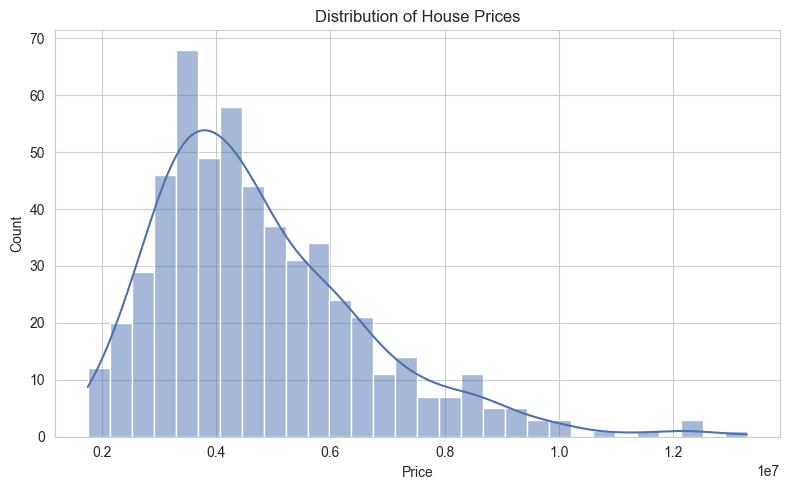

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("charts/chart1_price_distribution.png", dpi=150)
plt.show()

### Chart 2: Correlation Heatmap

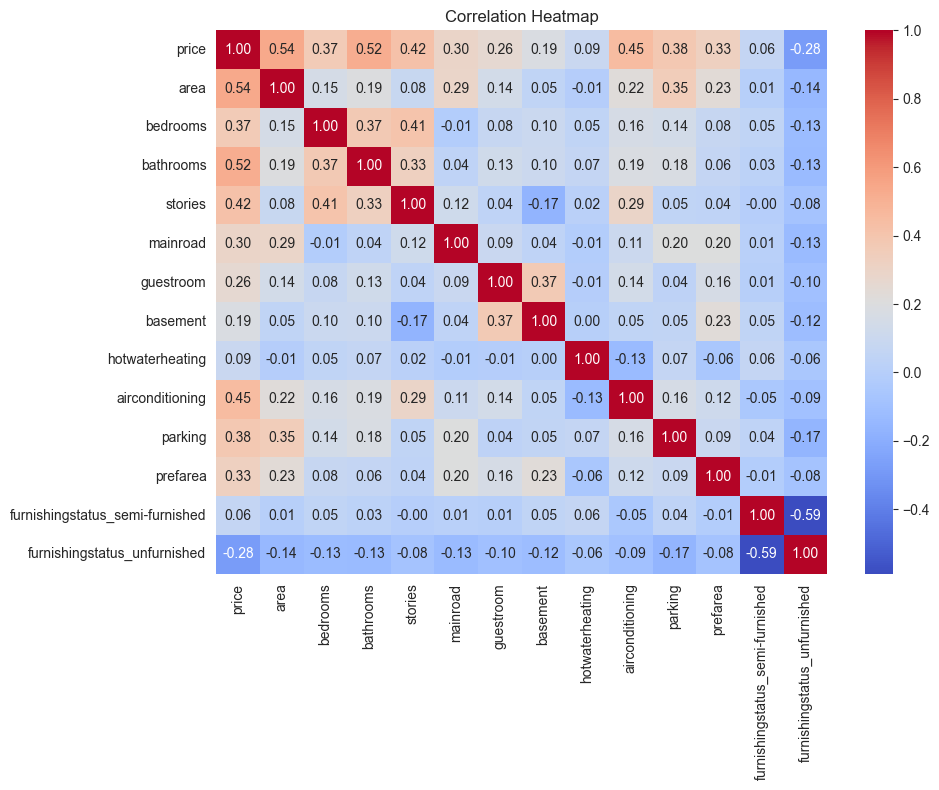

In [16]:
plt.figure(figsize=(10, 8))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/chart2_correlation_heatmap.png", dpi=150)
plt.show()

### Chart 3: Actual vs Predicted Price (Random Forest)

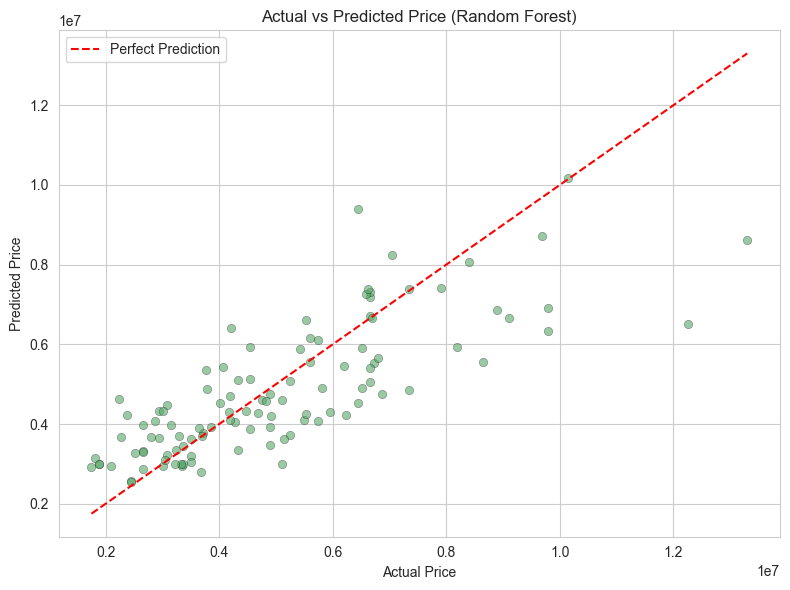

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_rf, alpha=0.6, color="#55A868", edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.legend()
plt.tight_layout()
plt.savefig("charts/chart3_actual_vs_predicted.png", dpi=150)
plt.show()

In [18]:
# Which features matter most? (Random Forest feature importance)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

area                               0.467809
bathrooms                          0.152635
airconditioning                    0.060260
parking                            0.057557
stories                            0.057045
bedrooms                           0.047544
furnishingstatus_unfurnished       0.036974
basement                           0.032418
prefarea                           0.028316
hotwaterheating                    0.018333
guestroom                          0.017916
furnishingstatus_semi-furnished    0.013178
mainroad                           0.010015
dtype: float64

## Task 5 — Insights & Summary

**Which features influence house price the most?**
Area is by far the strongest driver of price, followed by the number of bathrooms. Air conditioning, parking, and the number of stories also matter, while features like the main-road location and guest rooms have a smaller but still positive effect on price.

**How accurate was the model (in plain terms)?**
The Linear Regression model explains about 65% of the variation in house prices (R² ≈ 0.65), with an average prediction error of roughly ₹9.7 lakh. That means our predictions are usually in the right ballpark but can be off by a meaningful margin for unusual properties — good enough for a rough estimate, not for a precise valuation.

**What surprised us in the data?**
Bathrooms had a bigger effect on price than bedrooms — a home with more bathrooms commands a noticeably higher price even after accounting for area. Also, simple Linear Regression matched (and even slightly beat) the more complex Random Forest model, showing that more complexity doesn't always mean better results on a small, mostly-linear dataset.

**One recommendation for a real estate business:**
Since area and bathroom count are the biggest price drivers, a real estate business should prioritize highlighting these two features prominently in listings and pricing strategy. Renovating to add a bathroom may offer a stronger return on investment than adding an extra bedroom in the same footprint.